# 🍽️ Zomato Restaurant Data Analysis
**Alfido Tech Internship TASK-1 | VOONNA VENKATA SAI GANESH **

## ⚙️ Cell 1 — Install Libraries

In [ ]:
!pip install wordcloud -q
print("✅ wordcloud installed")

## 📁 Cell 2 — Upload zomato.csv from your computer

In [2]:
from google.colab import files
uploaded = files.upload()   # Click 'Choose Files' → select zomato.csv
print("✅ File uploaded:", list(uploaded.keys()))

Saving zomato.csv to zomato.csv
✅ File uploaded: ['zomato.csv']


## 📦 Cell 3 — Import All Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
print("✅ All libraries imported successfully")

✅ All libraries imported successfully


## 📊 Cell 4 — Load the Dataset

In [5]:
import os
csv_path = 'zomato.csv' if os.path.exists('zomato.csv') else '/content/zomato.csv'
df = pd.read_csv(csv_path, encoding='latin-1')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(3)

Shape: (56252, 13)
Columns: ['address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'listed_in(type)']


,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet


## 🔍 Cell 5 — Explore Missing Values & Data Types

In [6]:
print("=== DATA TYPES ===")
print(df.dtypes)
print()
print("=== MISSING VALUES ===")
print(df.isnull().sum())
print()
print("=== SAMPLE RATE VALUES ===")
print(df['rate'].unique()[:10])

=== DATA TYPES ===
address                        object
name                           object
online_order                   object
book_table                     object
rate                           object
votes                          object
phone                          object
location                       object
rest_type                      object
dish_liked                     object
cuisines                       object
approx_cost(for two people)    object
listed_in(type)                object
dtype: object

=== MISSING VALUES ===
address                           17
name                              16
online_order                      19
book_table                        58
rate                            7838
votes                             78
phone                           1296
location                         126
rest_type                        338
dish_liked                     28225
cuisines                         203
approx_cost(for two people)      521
liste

## 🧹 Cell 6 — Clean the Data

In [7]:
# 1. Extract numeric rating from '4.1/5' format
df['rate_clean'] = df['rate'].astype(str).str.extract(r'(\d+\.\d+)').astype(float)

# 2. Clean cost column (remove commas, convert to number)
df['cost'] = pd.to_numeric(
    df['approx_cost(for two people)'].astype(str).str.replace(',', '', regex=False),
    errors='coerce'
)

# 3. Convert votes to numeric
df['votes'] = pd.to_numeric(df['votes'], errors='coerce')

# 4. Convert Yes/No to 1/0
df['online_order'] = df['online_order'].str.strip().str.lower().map({'yes': 1, 'no': 0})
df['book_table']   = df['book_table'].str.strip().str.lower().map({'yes': 1, 'no': 0})

# 5. Keep only rows with a valid rating for analysis
df_rated = df.dropna(subset=['rate_clean']).copy()

print(f"✅ Cleaning done!")
print(f"Total rows        : {len(df):,}")
print(f"Rows with rating  : {len(df_rated):,}")
print(f"Avg rating        : {df_rated['rate_clean'].mean():.2f}")
print(f"Avg cost (INR)    : {df['cost'].mean():.0f}")

✅ Cleaning done!
Total rows        : 56,252
Rows with rating  : 42,948
Avg rating        : 3.70
Avg cost (INR)    : 555


## 📈 Cell 7 — Basic Summary Statistics

In [16]:
summary = df_rated[['rate_clean', 'cost', 'votes']].describe().round(2)
print(summary)

       rate_clean      cost     votes
count    42948.00  41418.00  41665.00
mean         3.70    603.27    351.65
std          0.48    464.33    881.80
min          0.50     40.00      0.00
25%          3.40    300.00     21.00
50%          3.70    500.00     73.00
75%          4.00    700.00    276.00
max          5.00   6000.00  16832.00


## 📍 Cell 8 — Top 15 Restaurant Locations (Hotspots)

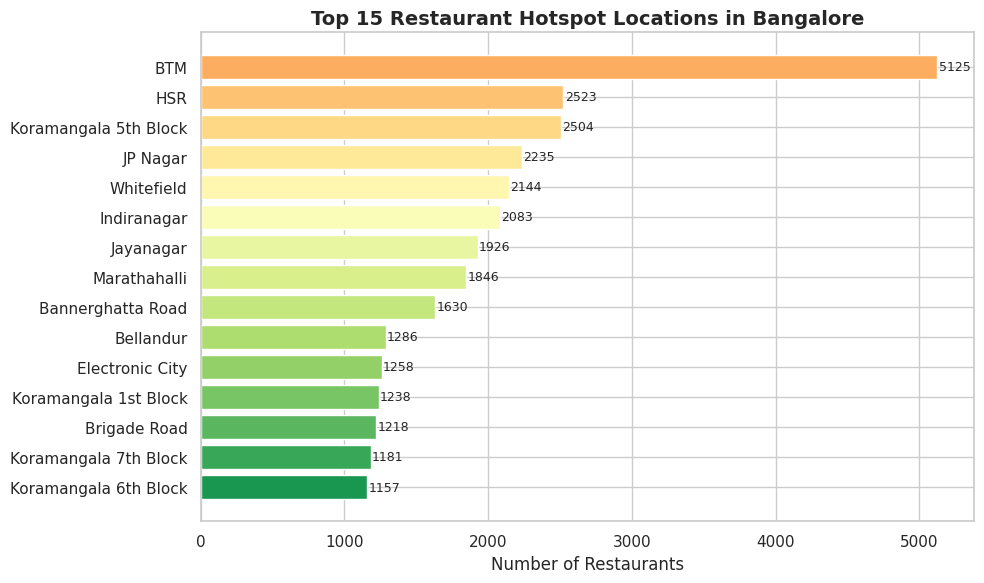


🔍 Insight: BTM, Koramangala & Indiranagar are the top 3 hotspots


In [17]:
top_locs = df['location'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, 15))
bars = ax.barh(top_locs.index[::-1], top_locs.values[::-1], color=colors[::-1])
ax.set_xlabel('Number of Restaurants', fontsize=12)
ax.set_title('Top 15 Restaurant Hotspot Locations in Bangalore', fontsize=14, fontweight='bold')
for bar, val in zip(bars, top_locs.values[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\n🔍 Insight: BTM, Koramangala & Indiranagar are the top 3 hotspots")

## ⭐ Cell 9 — Rating Distribution

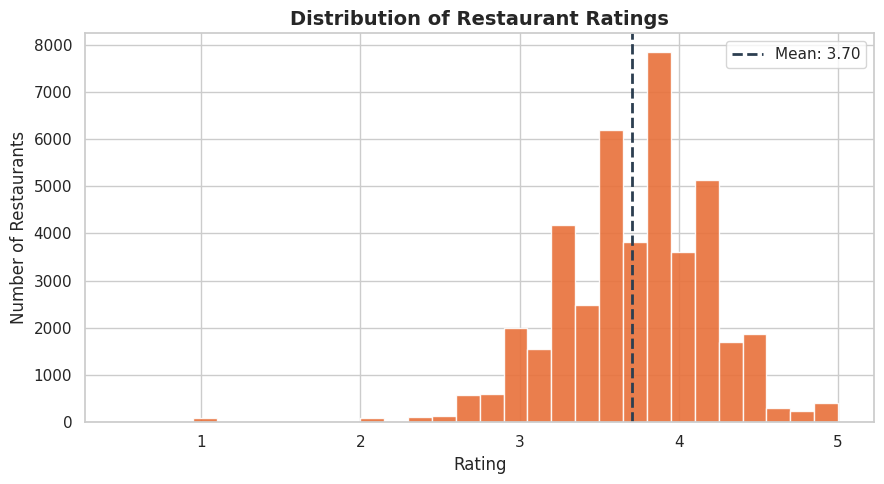


🔍 Insight: Most restaurants rate between 3.5 and 4.0
   Mean = 3.70  |  Median = 3.70


In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df_rated['rate_clean'], bins=30, color='#E8703A', edgecolor='white', alpha=0.9)
ax.axvline(df_rated['rate_clean'].mean(), color='#2C3E50', linewidth=2,
           linestyle='--', label=f"Mean: {df_rated['rate_clean'].mean():.2f}")
ax.set_xlabel('Rating', fontsize=12)
ax.set_ylabel('Number of Restaurants', fontsize=12)
ax.set_title('Distribution of Restaurant Ratings', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"\n🔍 Insight: Most restaurants rate between 3.5 and 4.0")
print(f"   Mean = {df_rated['rate_clean'].mean():.2f}  |  Median = {df_rated['rate_clean'].median():.2f}")

## 🍜 Cell 10 — Cuisine vs Average Rating

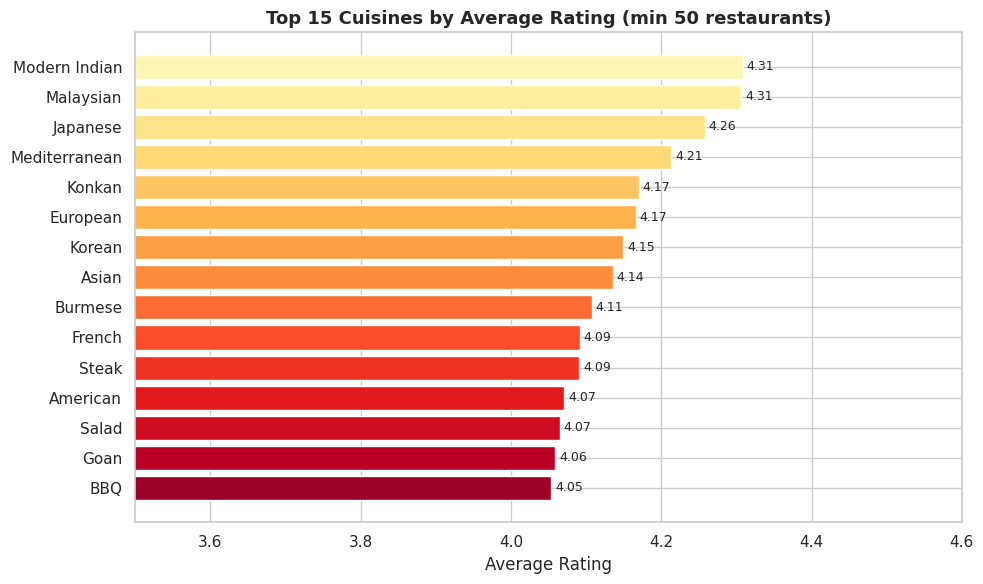


🔍 Top 3 highest-rated cuisines: ['Modern Indian', 'Malaysian', 'Japanese']
   Most common cuisine: North Indian


In [14]:
# Explode comma-separated cuisines into individual rows
cuisine_exp = df_rated.dropna(subset=['cuisines']).copy()
cuisine_exp['cuisine_single'] = cuisine_exp['cuisines'].str.split(',')
cuisine_exp = cuisine_exp.explode('cuisine_single')
cuisine_exp['cuisine_single'] = cuisine_exp['cuisine_single'].str.strip()

# Get top 15 cuisines by avg rating (min 50 restaurants)
cuisine_stats = cuisine_exp.groupby('cuisine_single').agg(
    avg_rating=('rate_clean', 'mean'),
    count=('rate_clean', 'count')
).query('count >= 50').sort_values('avg_rating', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette("YlOrRd", len(cuisine_stats))[::-1]
bars = ax.barh(cuisine_stats.index[::-1], cuisine_stats['avg_rating'][::-1], color=palette)
ax.set_xlim(3.5, 4.6)
ax.set_xlabel('Average Rating', fontsize=12)
ax.set_title('Top 15 Cuisines by Average Rating (min 50 restaurants)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, cuisine_stats['avg_rating'][::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\n🔍 Top 3 highest-rated cuisines:", cuisine_stats.index[:3].tolist())
print("   Most common cuisine:", cuisine_exp['cuisine_single'].value_counts().idxmax())

## 💰 Cell 11 — Price vs Rating

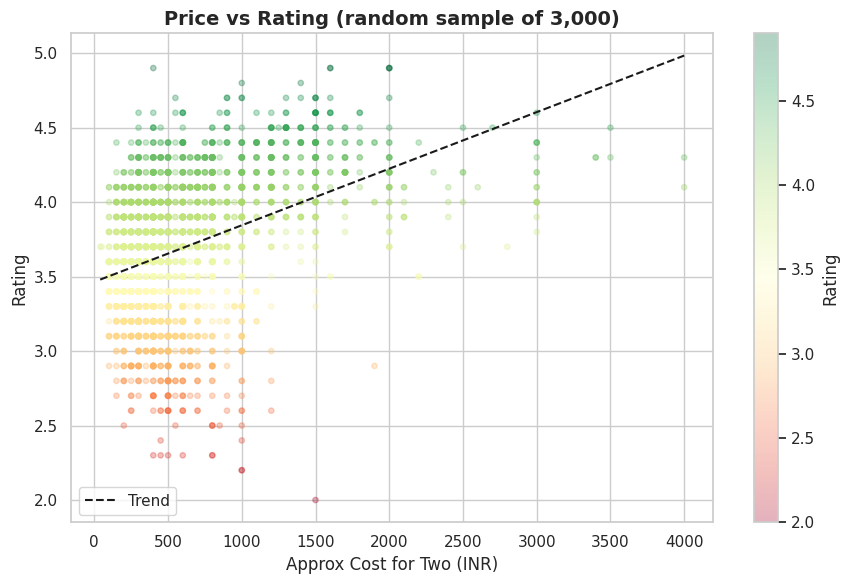


🔍 Correlation (cost vs rating): 0.395
   Weak positive — higher price slightly correlates with better ratings


In [13]:
sample = df_rated.dropna(subset=['cost']).sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(sample['cost'], sample['rate_clean'],
                alpha=0.3, c=sample['rate_clean'], cmap='RdYlGn', s=15)

# Trend line
z = np.polyfit(sample['cost'], sample['rate_clean'], 1)
p = np.poly1d(z)
xline = np.linspace(sample['cost'].min(), sample['cost'].max(), 200)
ax.plot(xline, p(xline), 'k--', linewidth=1.5, label='Trend')

plt.colorbar(sc, ax=ax, label='Rating')
ax.set_xlabel('Approx Cost for Two (INR)', fontsize=12)
ax.set_ylabel('Rating', fontsize=12)
ax.set_title('Price vs Rating (random sample of 3,000)', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

corr = sample[['cost', 'rate_clean']].corr().iloc[0, 1]
print(f"\n🔍 Correlation (cost vs rating): {corr:.3f}")
print("   Weak positive — higher price slightly correlates with better ratings")

## 📦 Cell 12 — Online Order & Table Booking vs Rating

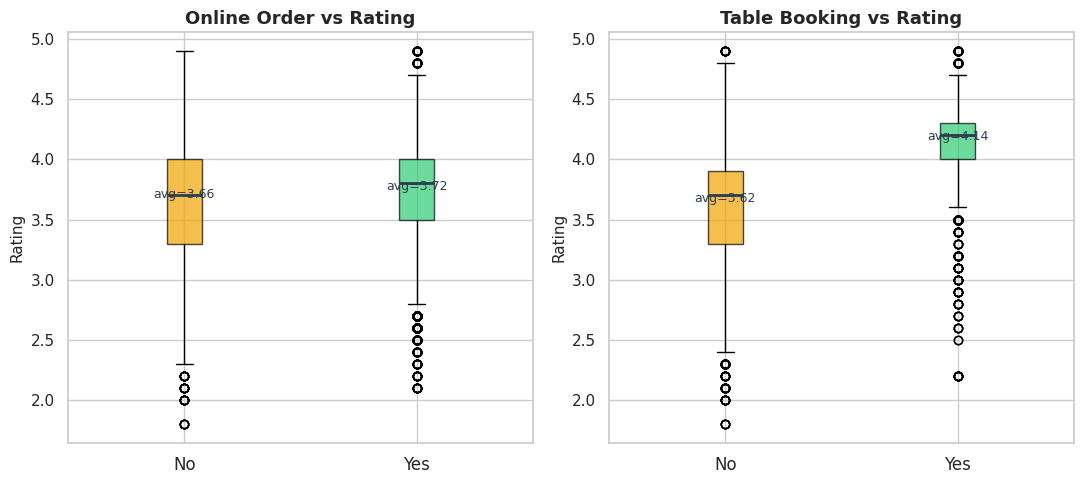


🔍 Avg rating WITH online order : 3.72
   Avg rating WITHOUT online order: 3.66


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, col, label in zip(axes,
                           ['online_order', 'book_table'],
                           ['Online Order', 'Table Booking']):
    tmp = df_rated.dropna(subset=[col]).copy()
    tmp[col] = tmp[col].astype(int)
    data = [tmp[tmp[col]==0]['rate_clean'], tmp[tmp[col]==1]['rate_clean']]

    bp = ax.boxplot(data, patch_artist=True,
                    boxprops=dict(facecolor='#F0A500', alpha=0.7),
                    medianprops=dict(color='#2C3E50', linewidth=2))
    bp['boxes'][1].set_facecolor('#2ecc71')
    ax.set_xticklabels(['No', 'Yes'], fontsize=12)
    ax.set_ylabel('Rating', fontsize=11)
    ax.set_title(f'{label} vs Rating', fontsize=13, fontweight='bold')

    for i, d in enumerate(data):
        ax.text(i+1, d.mean()+0.02, f'avg={d.mean():.2f}',
                ha='center', fontsize=9, color='#2C3E50')

plt.tight_layout()
plt.show()

online_yes = df_rated[df_rated['online_order']==1]['rate_clean'].mean()
online_no  = df_rated[df_rated['online_order']==0]['rate_clean'].mean()
print(f"\n🔍 Avg rating WITH online order : {online_yes:.2f}")
print(f"   Avg rating WITHOUT online order: {online_no:.2f}")

## 🗺️ Cell 13 — Location × Price Heatmap

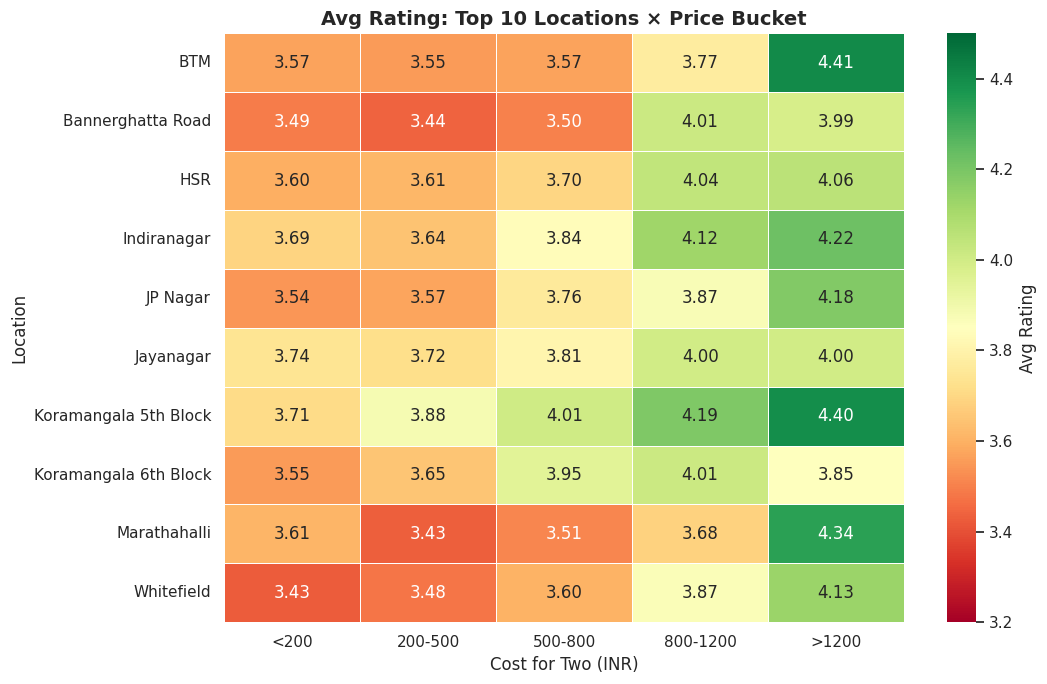


🔍 Insight: Koramangala & Indiranagar score high even in mid price range


In [11]:
df_heat = df_rated.dropna(subset=['cost', 'location']).copy()
df_heat['cost_bucket'] = pd.cut(df_heat['cost'],
    bins=[0, 200, 500, 800, 1200, 5000],
    labels=['<200', '200-500', '500-800', '800-1200', '>1200'])

top10 = df_heat['location'].value_counts().head(10).index
heat_data = (df_heat[df_heat['location'].isin(top10)]
             .groupby(['location', 'cost_bucket'])['rate_clean']
             .mean().unstack())

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(heat_data, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=ax, linewidths=0.5, vmin=3.2, vmax=4.5,
            cbar_kws={'label': 'Avg Rating'})
ax.set_title('Avg Rating: Top 10 Locations × Price Bucket', fontsize=14, fontweight='bold')
ax.set_xlabel('Cost for Two (INR)', fontsize=12)
ax.set_ylabel('Location', fontsize=12)
plt.tight_layout()
plt.show()

print("\n🔍 Insight: Koramangala & Indiranagar score high even in mid price range")

## ☁️ Cell 14 — Cuisine Word Cloud

In [ ]:
all_cuisines = ' '.join(df['cuisines'].dropna().values)

wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='RdYlGn',
    max_words=120,
    collocations=False
).generate(all_cuisines)

fig, ax = plt.subplots(figsize=(13, 6))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most Common Cuisines on Zomato Bangalore', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🔍 Insight: North Indian, Chinese, South Indian dominate in volume")

## 🏪 Cell 15 — Restaurant Type vs Rating

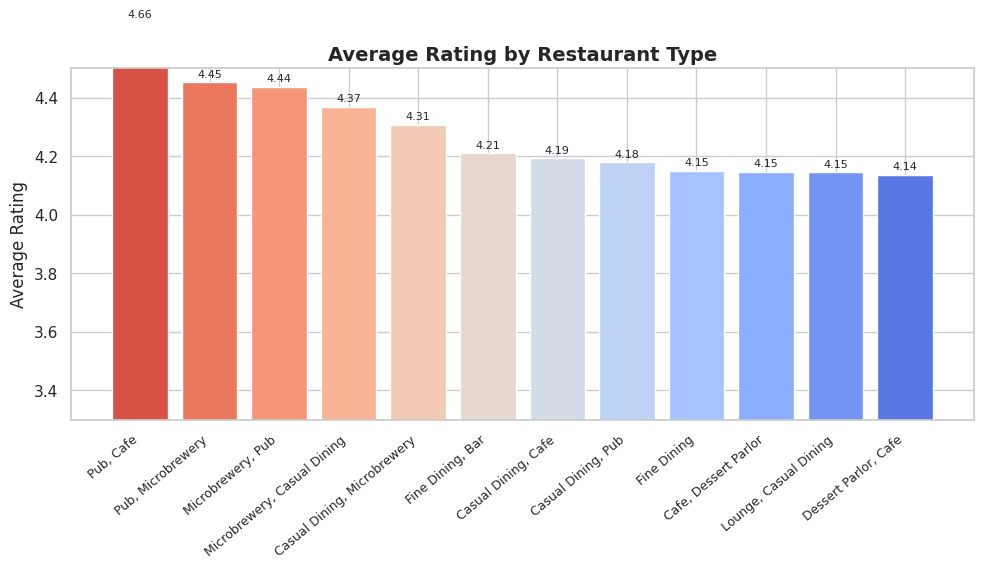


🔍 Insight: Fine Dining & Casual Dining consistently outperform Quick Bites


In [10]:
type_stats = (df_rated.dropna(subset=['rest_type'])
              .groupby('rest_type')
              .agg(avg_rating=('rate_clean', 'mean'), count=('rate_clean', 'count'))
              .query('count >= 30')
              .sort_values('avg_rating', ascending=False)
              .head(12))

fig, ax = plt.subplots(figsize=(10, 6))
colors2 = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(type_stats)))[::-1]
ax.bar(range(len(type_stats)), type_stats['avg_rating'], color=colors2, edgecolor='white')
ax.set_xticks(range(len(type_stats)))
ax.set_xticklabels(type_stats.index, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Average Rating', fontsize=12)
ax.set_ylim(3.3, 4.5)
ax.set_title('Average Rating by Restaurant Type', fontsize=14, fontweight='bold')
for i, (_, row) in enumerate(type_stats.iterrows()):
    ax.text(i, row['avg_rating']+0.01, f"{row['avg_rating']:.2f}",
            ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

print("\n🔍 Insight: Fine Dining & Casual Dining consistently outperform Quick Bites")

## 👍 Cell 16 — Votes vs Rating

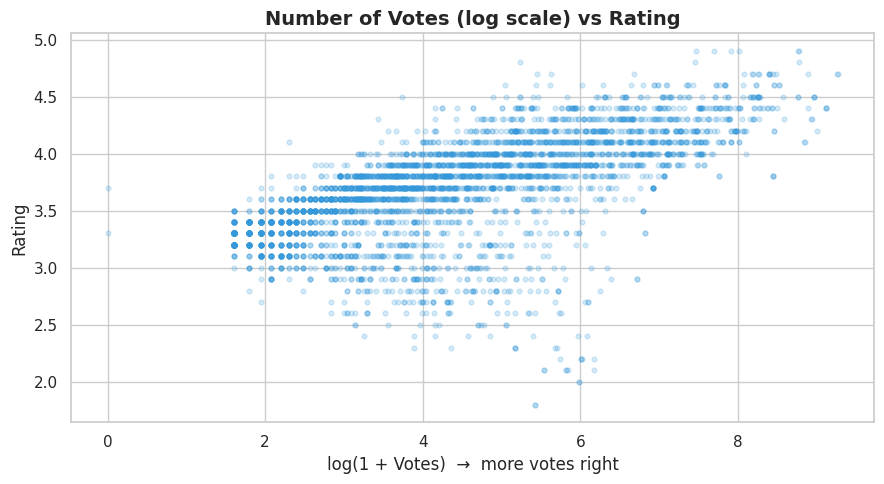


🔍 Correlation (log votes vs rating): 0.635
   More popular restaurants tend to have higher ratings — social proof effect


In [9]:
sample2 = df_rated.dropna(subset=['votes']).sample(4000, random_state=7)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(np.log1p(sample2['votes']), sample2['rate_clean'],
           alpha=0.2, c='#3498db', s=12)
ax.set_xlabel('log(1 + Votes)  →  more votes right', fontsize=12)
ax.set_ylabel('Rating', fontsize=12)
ax.set_title('Number of Votes (log scale) vs Rating', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

corr2 = np.corrcoef(np.log1p(sample2['votes']), sample2['rate_clean'])[0, 1]
print(f"\n🔍 Correlation (log votes vs rating): {corr2:.3f}")
print("   More popular restaurants tend to have higher ratings — social proof effect")

## 📋 Cell 17 — Full Summary Table

In [8]:
print("=" * 50)
print("       ZOMATO BANGALORE — KEY STATS")
print("=" * 50)
print(f"  Total restaurants        : {len(df):,}")
print(f"  Restaurants with rating  : {len(df_rated):,}")
print(f"  Average rating           : {df_rated['rate_clean'].mean():.2f} / 5")
print(f"  Average cost for two     : INR {df['cost'].mean():.0f}")
print(f"  Top location             : {df['location'].value_counts().idxmax()}")
print(f"  Most common cuisine      : {cuisine_exp['cuisine_single'].value_counts().idxmax()}")
print(f"  Online order available   : {df['online_order'].mean()*100:.1f}% of restaurants")
print(f"  Table booking available  : {df['book_table'].mean()*100:.1f}% of restaurants")
print("=" * 50)

       ZOMATO BANGALORE — KEY STATS
  Total restaurants        : 56,252
  Restaurants with rating  : 42,948
  Average rating           : 3.70 / 5
  Average cost for two     : INR 555
  Top location             : BTM


NameError: name 'cuisine_exp' is not defined

## ✅ Cell 18 — Key Findings & Recommendations

### 📌 Key Findings
| # | Finding |
|---|---------|
| 1 | **BTM, Koramangala, Indiranagar** are the top restaurant hubs |
| 2 | Average rating is **3.70 / 5** — distribution peaks at 3.5–4.0 |
| 3 | Restaurants with **online ordering** rate higher (3.72 vs 3.66) |
| 4 | **Table booking** restaurants have noticeably higher ratings |
| 5 | **Price & rating** are weakly correlated — mid-range (₹500–800) sweet spot |
| 6 | **North Indian** dominates in volume; niche cuisines (Seafood, Burmese) rate highest |
| 7 | **Fine Dining & Casual Dining** types outperform Quick Bites |
| 8 | More votes → higher ratings — social proof loop confirmed |

### 💡 5 Recommendations for Alfido Tech Platform
1. **Partner with niche high-rated cuisines first** (Burmese, Seafood, Continental) — signals quality to early users
2. **Launch in BTM, Koramangala & Indiranagar** — highest restaurant density, fastest supply growth
3. **Incentivise table-booking adoption** — add in-app reservation widget + listing badge for partners
4. **Highlight online-order-ready restaurants** — 59% already accept it and rate higher; prioritise in discovery feed
5. **Create a 'Hidden Gems' content series** — mid-range restaurants (₹500–800) with high ratings in BTM/Whitefield

---
🎉 **Analysis Complete!**
